# 10.1 Similarity and Distance in Data Analysis

In this notebook, the goal is to build an intuitive understanding of:
- what similarity and distance mean,
- the difference between Euclidean distance, cosine similarity, and Jaccard similarity,
- why scaling matters when we work with distances.

The focus here is on the core concepts rather than on a specific application.


## What are similarity and distance?

Similarity measurement tries to quantify how close two observations are to each other.

In many cases, we do not calculate similarity directly, but rather distance:
- **small distance** -> higher similarity
- **large distance** -> lower similarity

What counts as "close" is not always the same:
- for numerical variables, **Euclidean distance** is often used,
- for vector-like representations, **cosine similarity** can be more useful,
- for binary or set-based data, **Jaccard similarity** is often a natural choice.


## Euclidean distance

Euclidean distance is the familiar everyday notion of distance that could be measured with a ruler.


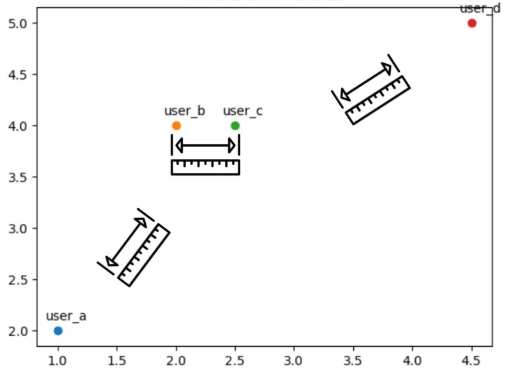

Two points are described by the formula:

$$ d(A, B) = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2} $$

Let's look at a very simple 2-dimensional example.


In [1]:
import math

# Function for computing Euclidean distance between two points
def euclidean_distance(point1, point2):
    squared_sum = 0  # We accumulate the sum of squared coordinate differences here

    # Go through the coordinates of the two points pairwise
    for a, b in zip(point1, point2):
        squared_sum += (a - b) ** 2
    return math.sqrt(squared_sum)

# Example points
A = [2, 3]
B = [5, 7]

# Compute the distance between A and B
distance = euclidean_distance(A, B)

# Print the results
print(f"Point A: {A}")
print(f"Point B: {B}")
print(f"Euclidean distance: {distance:.4f}")


Point A: [2, 3]
Point B: [5, 7]
Euclidean distance: 5.0000


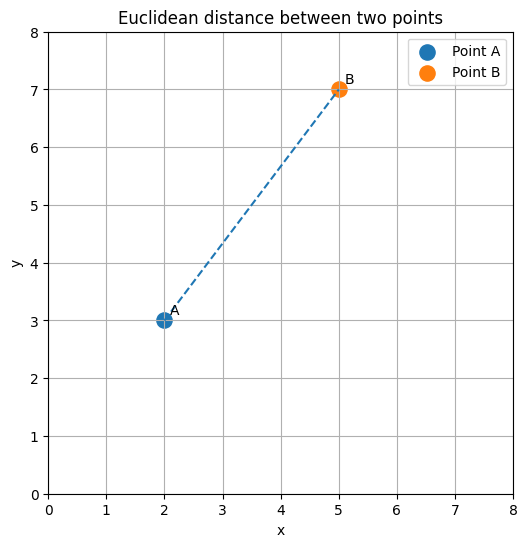

In [2]:
import matplotlib.pyplot as plt

# Create the figure with the given size
plt.figure(figsize=(6, 6))

# Plot points A and B
plt.scatter(A[0], A[1], s=120, label="Point A")
plt.scatter(B[0], B[1], s=120, label="Point B")

# Draw a dashed line between the two points
plt.plot([A[0], B[0]], [A[1], B[1]], linestyle="--")

# Add point labels
plt.text(A[0] + 0.1, A[1] + 0.1, "A")
plt.text(B[0] + 0.1, B[1] + 0.1, "B")

# Set axis limits
plt.xlim(0, 8)
plt.ylim(0, 8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euclidean distance between two points")

# Show legend and grid
plt.legend()
plt.grid(True)

plt.show()


**Interpretation:**

Euclidean distance tells us the straight-line distance between two points.

This works well when:
- the variables are numerical,
- we interpret them in the same "space",
- and their scales are comparable.


## Cosine similarity

Cosine similarity does not measure the physical distance between points, but rather whether two vectors **point in a similar direction**.


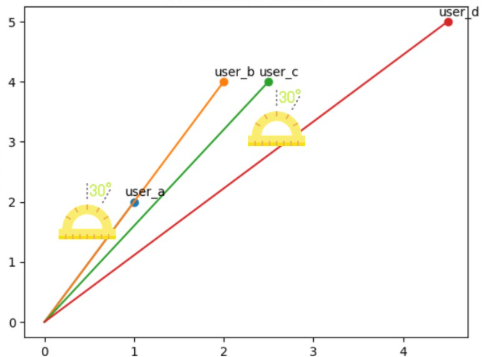

Formula:

$$ \text{cosine_similarity}(A, B) = \frac{A \cdot B}{||A|| \cdot ||B||} $$

Its value is:
- close to **1** if the two vectors have a very similar direction,
- close to **0** if they are nearly perpendicular,
- close to **-1** if they point in opposite directions.

Let's look at a few simple vectors.


In [3]:
import pandas as pd

# Example vectors
v1 = [1, 2]
v2 = [2, 4]      # Points in the same direction as v1
v3 = [2, -1]     # Points in a different direction
v4 = [-1, -2]    # Points in the opposite direction of v1


In [4]:
# Function for computing the dot product
def dot_product(a, b):
    total = 0

    # Go through the elements of the two vectors pairwise
    for x, y in zip(a, b):
        total += x * y

    return total


In [5]:
# Function for computing the length of a vector
def vector_length(v):
    squared_sum = 0

    # Sum the squares of the coordinates
    for x in v:
        squared_sum += x ** 2

    # Take the square root of the sum
    return math.sqrt(squared_sum)


In [6]:
# Function for computing cosine similarity
def cosine_sim(a, b):
    return dot_product(a, b) / (vector_length(a) * vector_length(b))


In [7]:
print(v1, v2, ' cosine similarity: ', round(cosine_sim(v1, v2), 2))
print(v1, v3, ' cosine similarity: ', round(cosine_sim(v1, v3), 2))
print(v1, v4, ' cosine similarity: ', round(cosine_sim(v1, v4), 2))


[1, 2] [2, 4]  cosine similarity:  1.0
[1, 2] [2, -1]  cosine similarity:  0.0
[1, 2] [-1, -2]  cosine similarity:  -1.0


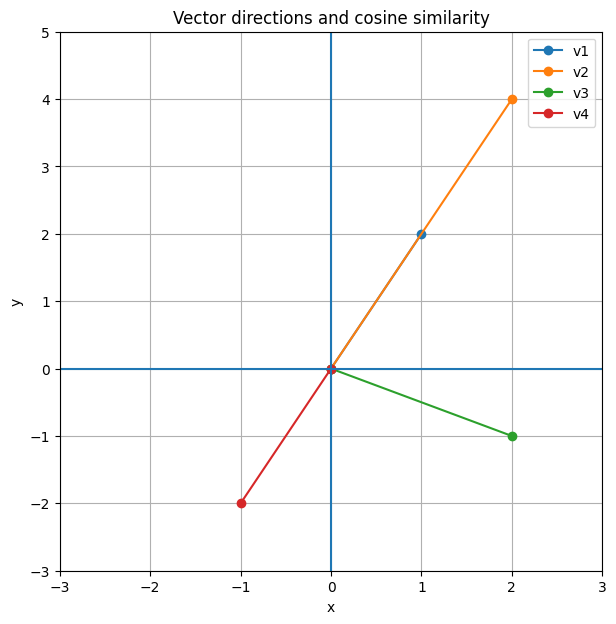

In [8]:
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(7, 7))

# Plot the vectors starting from the origin
plt.plot([0, v1[0]], [0, v1[1]], marker="o", label="v1")
plt.plot([0, v2[0]], [0, v2[1]], marker="o", label="v2")
plt.plot([0, v3[0]], [0, v3[1]], marker="o", label="v3")
plt.plot([0, v4[0]], [0, v4[1]], marker="o", label="v4")

# Draw axes
plt.axhline(0)
plt.axvline(0)

# Set axis limits
plt.xlim(-3, 3)
plt.ylim(-3, 5)

# Labels and title
plt.xlabel("x")
plt.ylabel("y")
plt.title("Vector directions and cosine similarity")

# Legend and grid
plt.legend()
plt.grid(True)

# Show the figure
plt.show()


**What do we see?**
- `v1` and `v2` point in the same direction, so their cosine similarity is close to **1**.
- `v1` and `v4` point in opposite directions, so their cosine similarity is **-1**.
- `v1` and `v3` do not point in a similar direction, so the value is much smaller.

Cosine similarity is especially useful when not the magnitude, but the **pattern** or **direction** matters.


## Comparing Euclidean distance and cosine similarity

These two measures do not capture the same thing.

Sometimes two vectors can be:
- far from each other in the Euclidean sense,
- yet still have a very similar direction.

Let's look at a short example.


In [9]:
v1 = [1, 1]
v2 = [10, 10]
v3 = [1, -1]

summary_df = pd.DataFrame({
    "Pair": ["v1 - v2", "v1 - v3"],
    "Euclidean distance": [
        euclidean_distance(v1, v2),
        euclidean_distance(v1, v3)
    ],
    "Cosine similarity": [
        cosine_sim(v1, v2),
        cosine_sim(v1, v3)
    ]
})

summary_df


,Pair,Euclidean distance,Cosine similarity
0,v1 - v2,12.727922,1.0
1,v1 - v3,2.000000,0.0


**Interpretation:**
- `v1` and `v2` are far apart because one is much larger, but they point in the same direction, so their cosine similarity is very high.
- `v1` and `v3` may be closer in distance, yet represent a completely different direction.

This is why we always need to think carefully about whether, in the given problem:
- **magnitude** matters,
- or rather **structure / direction**.


## Why is scaling important?

In distance-based methods, variables on larger scales can easily dominate those on smaller scales.

For example:
- age may range between 18 and 70,
- income may be several hundred thousand or even several million.

In that case, income differences appear with much larger numbers, so Euclidean distance will react almost entirely to that variable.

Let's look at a small example.


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

# Create example data
# The two variables are on very different scales:
# - age takes relatively small values
# - income is much larger in magnitude
df_people = pd.DataFrame({
    "age": [25, 27, 52, 54],
    "income": [250000, 900000, 260000, 920000]
}, index=["P1", "P2", "P3", "P4"])

# Display the original data
print("Original data:")
display(df_people)


Original data:


,age,income
P1,25,250000
P2,27,900000
P3,52,260000
P4,54,920000


In [11]:
# Compute Euclidean distances from the original data
raw_distances = pd.DataFrame(
    euclidean_distances(df_people),
    index=df_people.index,
    columns=df_people.index
)

# Display the distance matrix before scaling
print("Distance matrix without scaling:")
display(raw_distances.round(2))


Distance matrix without scaling:


,P1,P2,P3,P4
P1,0.00,650000.00,10000.04,670000.00
P2,650000.00,0.00,640000.00,20000.02
P3,10000.04,640000.00,0.00,660000.00
P4,670000.00,20000.02,660000.00,0.00


In [12]:
# Create the scaler object
scaler = StandardScaler()

# Scale the data
# After standardization, the variables are placed on more comparable scales
scaled_values = scaler.fit_transform(df_people)

# Convert the scaled values back into a DataFrame
df_people_scaled = pd.DataFrame(
    scaled_values,
    index=df_people.index,
    columns=df_people.columns
)

# Display the scaled data
print("Scaled data:")
display(df_people_scaled.round(2))


Scaled data:


,age,income
P1,-1.07,-1.01
P2,-0.92,0.97
P3,0.92,-0.98
P4,1.07,1.03


In [13]:
# Compute Euclidean distances from the scaled data
scaled_distances = pd.DataFrame(
    euclidean_distances(df_people_scaled),
    index=df_people.index,
    columns=df_people.index
)

# Display the distance matrix after scaling
print("Distance matrix after scaling:")
display(scaled_distances.round(2))


Distance matrix after scaling:


,P1,P2,P3,P4
P1,0.00,1.99,1.99,2.96
P2,1.99,0.00,2.69,2.00
P3,1.99,2.69,0.00,2.02
P4,2.96,2.00,2.02,0.00


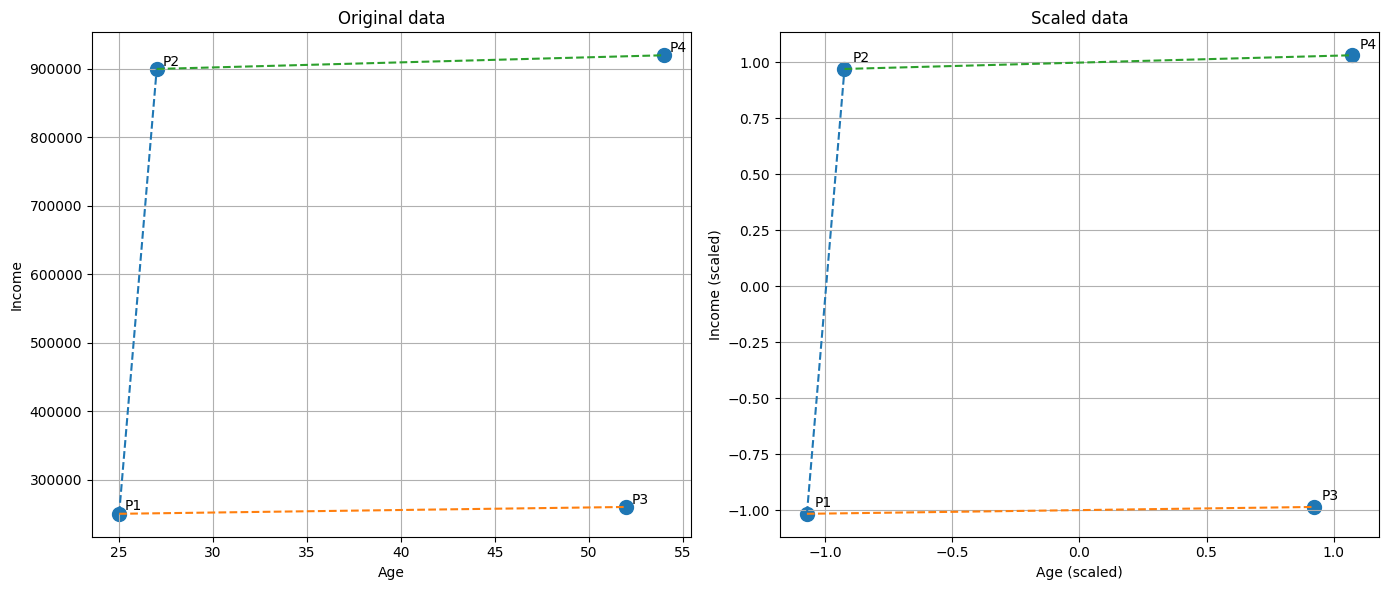

In [14]:
# Create two side-by-side figures
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original data
axes[0].scatter(df_people["age"], df_people["income"], s=100)

# Label the points
for idx in df_people.index:
    axes[0].text(
        df_people.loc[idx, "age"] + 0.3,
        df_people.loc[idx, "income"] + 5000,
        idx
    )

# Draw a few distances
pairs = [("P1", "P2"), ("P1", "P3"), ("P2", "P4")]

for p1, p2 in pairs:
    axes[0].plot(
        [df_people.loc[p1, "age"], df_people.loc[p2, "age"]],
        [df_people.loc[p1, "income"], df_people.loc[p2, "income"]],
        linestyle="--"
    )

axes[0].set_title("Original data")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Income")
axes[0].grid(True)

# Plot the scaled data
axes[1].scatter(df_people_scaled["age"], df_people_scaled["income"], s=100)

# Label the points
for idx in df_people_scaled.index:
    axes[1].text(
        df_people_scaled.loc[idx, "age"] + 0.03,
        df_people_scaled.loc[idx, "income"] + 0.03,
        idx
    )

# Draw the same distances
for p1, p2 in pairs:
    axes[1].plot(
        [df_people_scaled.loc[p1, "age"], df_people_scaled.loc[p2, "age"]],
        [df_people_scaled.loc[p1, "income"], df_people_scaled.loc[p2, "income"]],
        linestyle="--"
    )

axes[1].set_title("Scaled data")
axes[1].set_xlabel("Age (scaled)")
axes[1].set_ylabel("Income (scaled)")
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Takeaway:**
Without scaling, income dominates the distance calculation. After scaling, the variables play more comparable roles, so distances reflect similarity in a more balanced way.

That is why, before measuring similarity, it is often worth:
- standardizing,
- or applying another appropriate scaling method.


## Jaccard similarity

Jaccard similarity is especially useful for binary or set-like data.

It measures the proportion of shared elements relative to all elements where at least one of the two objects has a presence.

Formula:

$$ J(A, B) = \frac{|A \cap B|}{|A \cup B|} $$

Let's look at a simple movie-related example.


In [15]:
from sklearn.metrics import jaccard_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# Create a simple example movie dataset
# The values 0 and 1 indicate whether the given movie has the given genre characteristic
df_movies = pd.DataFrame({
    "Action": [1, 0, 1],
    "Comedy": [0, 1, 0],
    "Sci-Fi": [0, 0, 1],
    "Drama": [1, 1, 0]
}, index=["Movie_A", "Movie_B", "Movie_C"])

# Display the DataFrame
display(df_movies)


,Action,Comedy,Sci-Fi,Drama
Movie_A,1,0,0,1
Movie_B,0,1,0,1
Movie_C,1,0,1,0


In [16]:
# Define the movie pairs to compare
pairs = [("Movie_A", "Movie_B"), ("Movie_A", "Movie_C"), ("Movie_B", "Movie_C")]

# We collect the results for each pair in this list
rows = []

# Go through all movie pairs
for left, right in pairs:
    # Extract the binary feature vectors of the two movies
    a = df_movies.loc[left].values
    b = df_movies.loc[right].values

    # Compute the different similarity and distance measures
    rows.append({
        "Pair": f"{left} vs {right}",
        "Euclidean distance": euclidean_distances([a], [b])[0, 0],
        "Cosine similarity": cosine_similarity([a], [b])[0, 0],
        "Jaccard similarity": jaccard_score(a, b)
    })

# Arrange the results in a table and display them rounded
pd.DataFrame(rows).round(4)


,Pair,Euclidean distance,Cosine similarity,Jaccard similarity
0,Movie_A vs Movie_B,1.4142,0.5,0.3333
1,Movie_A vs Movie_C,1.4142,0.5,0.3333
2,Movie_B vs Movie_C,2.0000,0.0,0.0000


**Interpretation:**
Here the variables indicate whether a genre is present or not. In this setting, Jaccard similarity is often the most intuitive choice because it explicitly focuses on shared presences.

For this type of data, Euclidean distance often has a less natural interpretation.


## Exercise

The dataset below contains characteristics of a few students.

The numerical variables show how much time they spend studying and how many exercises they solved.

The binary variables indicate whether they used a given tool or topic.


In [17]:
import pandas as pd

df_students = pd.DataFrame({
    "tanulasi_ido": [2, 3, 8, 9],
    "feladatok_szama": [4, 5, 18, 20],
    "Python": [1, 1, 0, 0],
    "Excel": [1, 1, 1, 0],
    "SQL": [0, 1, 1, 1],
    "Vizualizacio": [1, 0, 1, 1]
}, index=["Diak_A", "Diak_B", "Diak_C", "Diak_D"])

df_students

,tanulasi_ido,feladatok_szama,Python,Excel,SQL,Vizualizacio
Diak_A,2,4,1,1,0,1
Diak_B,3,5,1,1,1,0
Diak_C,8,18,0,1,1,1
Diak_D,9,20,0,0,1,1


### Exercise 1
Examine the Euclidean distances based on the numerical variables.


In [8]:
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Data
df_students = pd.DataFrame({
    "tanulasi_ido": [2, 3, 8, 9],
    "feladatok_szama": [4, 5, 18, 20],
    "Python": [1, 1, 0, 0],
    "Excel": [1, 1, 1, 0],
    "SQL": [0, 1, 1, 1],
    "Vizualizacio": [1, 0, 1, 1]
}, index=["Diak_A", "Diak_B", "Diak_C", "Diak_D"])
numerical = df_students[["tanulasi_ido", "feladatok_szama"]]
euclidean_dist = pd.DataFrame(squareform(pdist(numerical, metric='euclidean')),
                              index=df_students.index, columns=df_students.index)
print("Exercise 1 - Euclidean distance (numerical):")
print(euclidean_dist)


Exercise 1 - Euclidean distance (numerical):
           Diak_A     Diak_B     Diak_C     Diak_D
Diak_A   0.000000   1.414214  15.231546  17.464249
Diak_B   1.414214   0.000000  13.928388  16.155494
Diak_C  15.231546  13.928388   0.000000   2.236068
Diak_D  17.464249  16.155494   2.236068   0.000000


### Exercise 2
Compare the results before and after scaling.


In [9]:
import pandas as pd

df_students = pd.DataFrame({
    "tanulasi_ido": [2, 3, 8, 9],
    "feladatok_szama": [4, 5, 18, 20],
    "Python": [1, 1, 0, 0],
    "Excel": [1, 1, 1, 0],
    "SQL": [0, 1, 1, 1],
    "Vizualizacio": [1, 0, 1, 1]
}, index=["Diak_A", "Diak_B", "Diak_C", "Diak_D"])

df_students

scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical)
euclidean_dist_scaled = pd.DataFrame(squareform(pdist(numerical_scaled, metric='euclidean')),
                                     index=df_students.index, columns=df_students.index)
print("\nExercise 2 - Euclidean distance (scaled numerical):")
print(euclidean_dist_scaled)


Exercise 2 - Euclidean distance (scaled numerical):
          Diak_A    Diak_B    Diak_C    Diak_D
Diak_A  0.000000  0.356244  2.752629  3.179695
Diak_B  0.356244  0.000000  2.424900  2.849949
Diak_C  2.752629  2.424900  0.000000  0.428152
Diak_D  3.179695  2.849949  0.428152  0.000000


### Exercise 3
Using the binary variables, examine Euclidean distance, cosine similarity, and Jaccard similarity.


In [10]:
import pandas as pd

df_students = pd.DataFrame({
    "tanulasi_ido": [2, 3, 8, 9],
    "feladatok_szama": [4, 5, 18, 20],
    "Python": [1, 1, 0, 0],
    "Excel": [1, 1, 1, 0],
    "SQL": [0, 1, 1, 1],
    "Vizualizacio": [1, 0, 1, 1]
}, index=["Diak_A", "Diak_B", "Diak_C", "Diak_D"])

df_students

binary = df_students[["Python", "Excel", "SQL", "Vizualizacio"]]
euclidean_binary = pd.DataFrame(squareform(pdist(binary, metric='euclidean')),
                                index=df_students.index, columns=df_students.index)
cosine_sim = pd.DataFrame(cosine_similarity(binary), index=df_students.index, columns=df_students.index)

def jaccard_similarity(X):
    n = X.shape[0]
    sim = pd.DataFrame(index=X.index, columns=X.index, dtype=float)
    for i in range(n):
        for j in range(n):
            a = X.iloc[i]
            b = X.iloc[j]
            sim.iloc[i,j] = (a & b).sum() / (a | b).sum()
    return sim

jaccard_sim = jaccard_similarity(binary)

print("\nEuclidean distance (binary):")
print(euclidean_binary)
print("\nCosine similarity (binary):")
print(cosine_sim)
print("\nJaccard similarity (binary):")
print(jaccard_sim)


Euclidean distance (binary):
          Diak_A    Diak_B    Diak_C    Diak_D
Diak_A  0.000000  1.414214  1.414214  1.732051
Diak_B  1.414214  0.000000  1.414214  1.732051
Diak_C  1.414214  1.414214  0.000000  1.000000
Diak_D  1.732051  1.732051  1.000000  0.000000

Cosine similarity (binary):
          Diak_A    Diak_B    Diak_C    Diak_D
Diak_A  1.000000  0.666667  0.666667  0.408248
Diak_B  0.666667  1.000000  0.666667  0.408248
Diak_C  0.666667  0.666667  1.000000  0.816497
Diak_D  0.408248  0.408248  0.816497  1.000000

Jaccard similarity (binary):
        Diak_A  Diak_B    Diak_C    Diak_D
Diak_A    1.00    0.50  0.500000  0.250000
Diak_B    0.50    1.00  0.500000  0.250000
Diak_C    0.50    0.50  1.000000  0.666667
Diak_D    0.25    0.25  0.666667  1.000000


### Exercise 4
Visualize the result.

Try to interpret:
- Which two students are most similar based on the numerical characteristics?
- Which two students are most similar based on the binary characteristics?
- Do you get the same pairs?


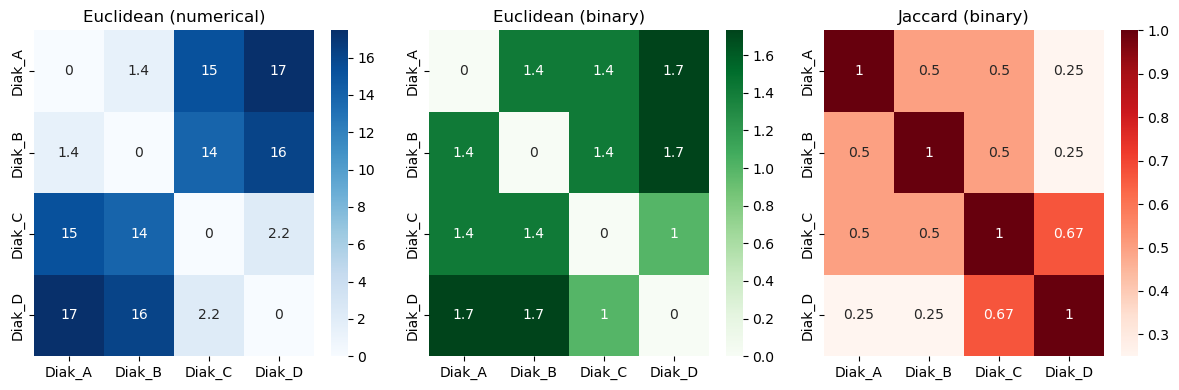

In [11]:
import pandas as pd

df_students = pd.DataFrame({
    "tanulasi_ido": [2, 3, 8, 9],
    "feladatok_szama": [4, 5, 18, 20],
    "Python": [1, 1, 0, 0],
    "Excel": [1, 1, 1, 0],
    "SQL": [0, 1, 1, 1],
    "Vizualizacio": [1, 0, 1, 1]
}, index=["Diak_A", "Diak_B", "Diak_C", "Diak_D"])

df_students

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1)
sns.heatmap(euclidean_dist, annot=True, cmap='Blues')
plt.title('Euclidean (numerical)')

plt.subplot(1,3,2)
sns.heatmap(euclidean_binary, annot=True, cmap='Greens')
plt.title('Euclidean (binary)')

plt.subplot(1,3,3)
sns.heatmap(jaccard_sim, annot=True, cmap='Reds')
plt.title('Jaccard (binary)')

plt.tight_layout()
plt.show()
